# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr
# Importar librerías



### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos

df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
df.head() # mostrar las primeras 5 filas


,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`
 
La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` se encuentra almacenada como float64 pese a representar una variable discreta. Si todos sus valores corresponden a números enteros, se recomienda convertirla a int para representar mejor la naturaleza del dato.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.


In [4]:
df["edad"] = df["edad"].astype(int) # Corregir el tipo de dato


In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [6]:
col_numericas = [
    "edad",
    "nivel_ingreso",
    "visitas_mes",
    "compras_mes",
    "gasto_publicidad_dirigida",
    "satisfaccion",
    "ingreso_anual"
]

df[col_numericas].describe()# Estadísticas descriptivas de variables numéricas


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


Diagnóstico inicial de variables numéricas

- `edad` — Los clientes tienen entre 18 y 75 años, con una mediana de 38 años, lo que indica una distribución centrada en adultos.
- `nivel_ingreso` — Presenta una amplia variabilidad (desde 8.000 hasta 74.791 aproximadamente), lo que sugiere una población con distintos niveles socioeconómicos.
- `visitas_mes` — Los clientes realizan en promedio 10 visitas mensuales, con valores entre 1 y 25, sin observarse cifras inusuales en esta etapa.
- `compras_mes` — La mayoría de los clientes realiza pocas compras al mes (mediana de 1), aunque algunos alcanzan hasta 8 compras.
- `gasto_publicidad_dirigida` — El gasto promedio es de 20,15, con un máximo de 75,51, lo que indica diferencias importantes en la inversión publicitaria destinada a cada cliente.
- `satisfaccion` — La satisfacción se encuentra en una escala de 1 a 5, con una media de 3,6, lo que refleja una valoración general moderadamente positiva.
- `ingreso_anual` — Existe una alta dispersión en los ingresos anuales, con valores entre 0 y 244,69, por lo que será conveniente revisar su distribución mediante gráficos para detectar posibles valores atípicos.

#### Explorar variables binarias

In [7]:
col_binarias = ["miembro_premium", "abandono"]

for col in col_binarias:
    print(f"\n{col}")
    print(df[col].value_counts())
    print("\nProporción:")
    print(df[col].value_counts(normalize=True)) # Verificar que cada columna tenga únicamente dos valores posibles



miembro_premium
0    12911
1     2089
Name: miembro_premium, dtype: int64

Proporción:
0    0.860733
1    0.139267
Name: miembro_premium, dtype: float64

abandono
0    12739
1     2261
Name: abandono, dtype: int64

Proporción:
0    0.849267
1    0.150733
Name: abandono, dtype: float64


Diagnóstico inicial de variables binarias

- `miembro_premium` — La variable presenta únicamente los valores 0 y 1, por lo que está correctamente codificada como binaria. Aproximadamente 14% de los clientes pertenece al programa Premium.
- `abandono` — La variable contiene únicamente los valores 0 y 1, sin categorías inválidas. La distribución muestra que 15% de los clientes abandonó el servicio.

#### Explorar variables categóricas

In [8]:
col_categoricas = ["tipo_dispositivo", "region"]

for col in col_categoricas:
    print(f"\n{col}")
    print("Valores únicos:", df[col].nunique()) # Verificar el número de valores únicos por variable categórica



tipo_dispositivo
Valores únicos: 3

region
Valores únicos: 4


In [9]:

for col in col_categoricas:
    print(f"\nDistribución de {col}")
    print(df[col].value_counts())
# Explorar variables categóricas y cómo se distribuyen



Distribución de tipo_dispositivo
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Distribución de region
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — La variable presenta tres categorías correctamente tipificadas (móvil, escritorio y tablet), sin valores inesperados. El dispositivo más utilizado es móvil, con aproximadamente dos tercios de los registros, seguido por escritorio y, en menor medida, tablet.
- `region` — La variable contiene cuatro regiones (norte, sur, este y oeste), todas con una representación importante en el conjunto de datos. La región norte concentra la mayor cantidad de clientes, mientras que este es la menos frecuente, aunque la distribución no presenta diferencias extremas.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

Text(0.5, 1.0, 'Correlation Heatmap - NovaRetail+')

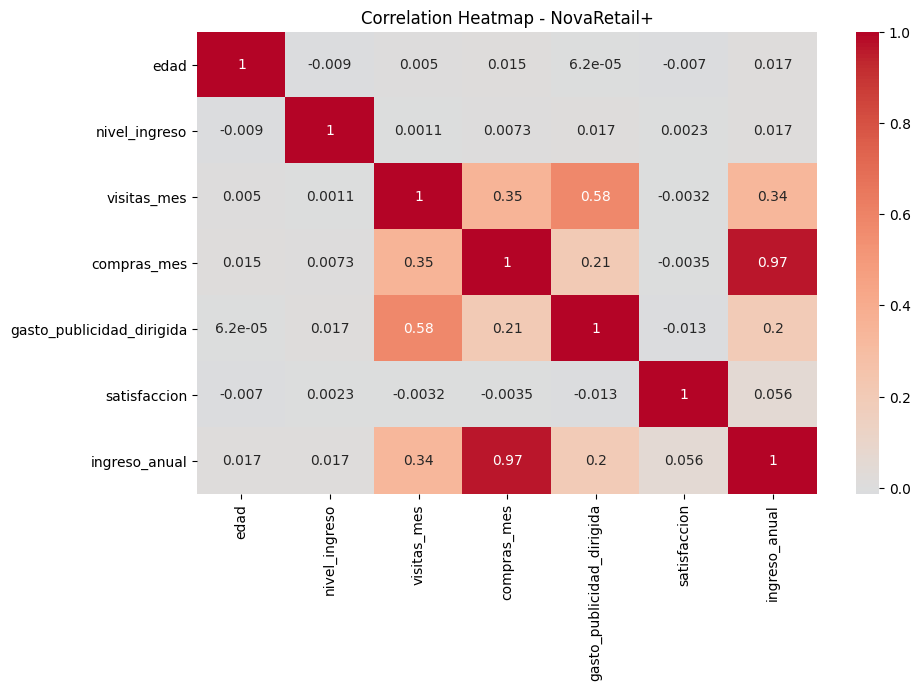

In [10]:

corr = df[col_numericas].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - NovaRetail+") # Visualizar la matriz de correlación para identificar relaciones



✍️ **Comentario**: 

Observaciones generales (Heatmap)

La mayoría de las variables presentan correlaciones débiles o cercanas a cero, lo que indica una baja asociación lineal entre ellas.
Se observan algunas correlaciones positivas de mayor magnitud, destacándose la relación entre compras_mes e ingreso_anual (0,97) y, en menor medida, entre visitas_mes y gasto_publicidad_dirigida (0,58).
Variables como edad, nivel_ingreso y satisfaccion muestran correlaciones muy bajas con el resto de las variables numéricas analizadas.

Observaciones respecto a `ingreso_anual`

ingreso_anual presenta una correlación muy fuerte y positiva con compras_mes (0,97).
También muestra una correlación positiva moderada con visitas_mes (0,34) y una correlación débil con gasto_publicidad_dirigida (0,20).
No se observan asociaciones lineales relevantes entre ingreso_anual y variables como edad, nivel_ingreso o satisfaccion.



### Scatterplot general

 * No se realizó un scatterplot general, ya que el heatmap permite visualizar de forma resumida las correlaciones entre todas las variables numéricas. Un scatterplot aporta mayor valor cuando se desea profundizar en una relación particular.

### Scatterplot para pares clave

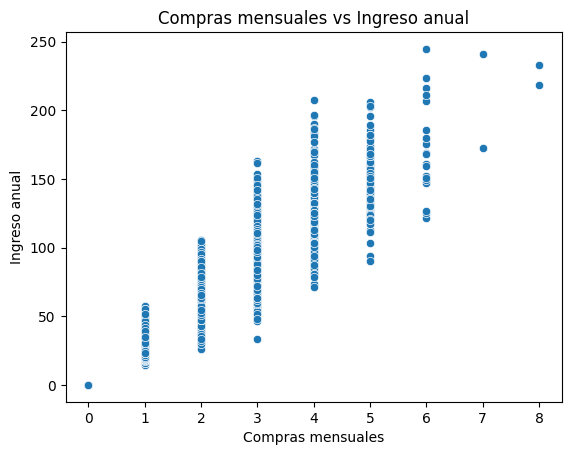

In [11]:


sns.scatterplot(
    data=df,
    x='compras_mes',
    y='ingreso_anual'
)

plt.title('Compras mensuales vs Ingreso anual')
plt.xlabel('Compras mensuales')
plt.ylabel('Ingreso anual')
plt.show()

# Visualizar pares de variables con relaciones moderadas o fuertes


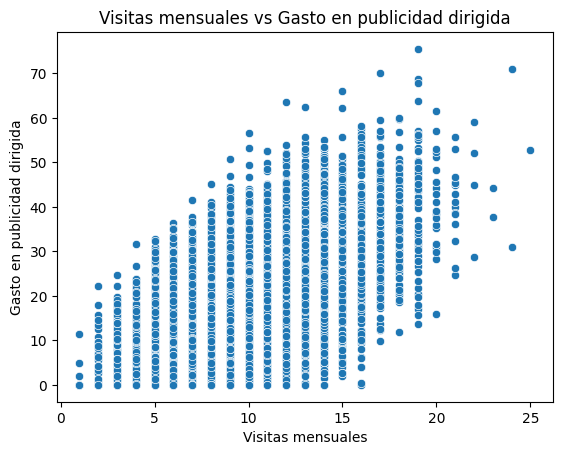

In [12]:


sns.scatterplot(
    data=df,
    x='visitas_mes',
    y='gasto_publicidad_dirigida'
)

plt.title('Visitas mensuales vs Gasto en publicidad dirigida')
plt.xlabel('Visitas mensuales')
plt.ylabel('Gasto en publicidad dirigida')
plt.show()



Observaciones iniciales (Scatterplot)

**compras_mes vs ingreso_anual**
- Dirección: Se observa una relación positiva; a medida que aumenta el número de compras mensuales, también tiende a aumentar el ingreso anual.
- Dispersión: Baja a moderada. Los puntos se concentran alrededor de una tendencia creciente bien definida, aunque existe cierta variabilidad para un mismo número de compras.
- Outliers: No se identifican valores atípicos claramente aislados del resto de las observaciones.
- Posible colinealidad: La fuerte alineación de los puntos es consistente con la alta correlación observada en el heatmap, por lo que podría existir colinealidad entre ambas variables.


**visitas_mes vs gasto_publicidad_dirigida**
- Dirección: Se observa una relación positiva; valores más altos de visitas mensuales tienden a asociarse con mayores valores de gasto en publicidad dirigida.
- Dispersión: Moderada. Aunque existe una tendencia creciente, la variabilidad de los datos es mayor que en el gráfico anterior.
- Outliers: Se observan algunos valores elevados de gasto, pero permanecen cercanos a la distribución general y no destacan como outliers claramente aislados.
- Posible colinealidad: No se aprecia una colinealidad fuerte; la dispersión de los puntos indica que la asociación es moderada.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [13]:
df['compras_mes'].corr(df['ingreso_anual'], method='pearson') # Calcular correlación entre variables relevantes


0.9671485435708564

In [14]:
df['visitas_mes'].corr(df['gasto_publicidad_dirigida'], method='spearman') # Calcular correlación entre variables relevantes


0.5592673242622609

Observaciones de correlación

**compras_mes vs ingreso_anual**
- Se observa una correlación positiva muy fuerte (r = 0,967), indicando una asociación lineal elevada entre ambas variables.
- La magnitud del coeficiente coincide con la tendencia observada en el scatterplot y sugiere una posible colinealidad entre las variables.

**visitas_mes vs gasto_publicidad_dirigida**
- Se observa una correlación positiva moderada (ρ = 0,559), lo que indica una asociación monotónica de intensidad media entre ambas variables.
- La magnitud del coeficiente es consistente con la dispersión observada en el scatterplot y no sugiere una colinealidad fuerte.

### Punto-biserial

In [15]:
pointbiserialr( df["abandono"], df["ingreso_anual"] ) # Calcular correlación entre variables relevantes


SignificanceResult(statistic=-0.002823934021617148, pvalue=0.7294691719078393)

In [16]:
pointbiserialr( df["miembro_premium"], df["ingreso_anual"] )

SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)

Observaciones Punto-biserial

**abandono vs ingreso_anual**
- La relación es negativa, pero de magnitud prácticamente nula.

**miembro_premium vs ingreso_anual**
- Relación positiva, pero de magnitud prácticamente nula. 

### V de Cramér

In [17]:
def cramers_v(df, col1, col2):

    tabla = pd.crosstab(df[col1], df[col2])

    chi2, _, _, _ = chi2_contingency(tabla)

    n = tabla.sum().sum()

    v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))

    return v # Función para calcular V de Cramér


In [18]:
cramers_v(df, "tipo_dispositivo", "miembro_premium") # Aplicar V de Cramér en variables relevantes



0.01972543445542166

Observaciones V de Cramér
**region vs tipo_dispositivo**

- Se obtuvo un V de Cramér = 0.020, lo que indica una asociación muy débil o prácticamente nula entre ambas variables categóricas.
- La distribución del tipo de dispositivo es similar entre las distintas regiones, por lo que no se observa una relación relevante entre estas variables.


## Sección 5 - Interpretación de resultados para el negocio

### Hallazgo 1 — Compras mensuales e ingreso anual

**Evidencia visual:** El scatterplot muestra una tendencia positiva clara entre compras_mes e ingreso_anual, con baja dispersión y sin outliers relevantes.

**Evidencia numérica:** Correlación de Pearson: r = 0.967.

**Interpretación**
Existe una asociación lineal muy fuerte y positiva entre ambas variables. Los clientes que realizan un mayor número de compras tienden a registrar mayores valores de ingreso anual generado para la empresa.

**No podemos afirmar**
No puede concluirse que aumentar la cantidad de compras provoque un incremento del ingreso anual, ya que el análisis es observacional y únicamente identifica una asociación.

**Implicación de negocio**  
Esta relación sugiere que ambas variables pueden utilizarse para identificar clientes de mayor valor y complementar procesos de segmentación o análisis de comportamiento.


### Hallazgo 2 — Visitas mensuales y gasto en publicidad dirigida

**Evidencia visual:** El scatterplot presenta una tendencia positiva con una dispersión moderada.  
**Evidencia numérica:** Correlación de Spearman: ρ = 0.559.

**Interpretación**  
Se observa una asociación positiva de magnitud moderada entre las visitas mensuales y el gasto en publicidad dirigida.

**No podemos afirmar**  
No puede concluirse que incrementar el gasto publicitario cause un aumento en las visitas, ni que un mayor número de visitas implique necesariamente una mayor inversión en publicidad.

**Implicación de negocio**  
La asociación observada indica que ambas variables podrían analizarse conjuntamente para estudiar el comportamiento de los usuarios y apoyar futuras estrategias de segmentación o marketing.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- El análisis se basa en medidas de correlación y asociación, por lo que no permite establecer relaciones de causalidad entre las variables.
- Solo se analizaron las variables incluidas en el dataset. Otros factores que podrían influir en el ingreso anual (por ejemplo, historial de compras, campañas de marketing, estacionalidad o antigüedad del cliente) no están disponibles.
- Las asociaciones identificadas se evaluaron principalmente de forma bivariada, por lo que no se consideró el efecto conjunto de múltiples variables sobre el ingreso anual.

### **Próximos pasos** 

- Segmentar a los clientes según su nivel de ingresos, frecuencia de compras o nivel de satisfacción para identificar diferencias en el ingreso anual generado.
- Incorporar nuevas variables de negocio que permitan ampliar el análisis de los factores asociados al ingreso anual.
- Analizar las variables que mostraron asociaciones moderadas o fuertes mediante técnicas estadísticas adicionales.